# Exploratory Data Analysis

**Project:** Team2-C3_OnlineShoppingBehavior

**Team:** Joel Cannon & Colman Connolly

**Date:** 2/22/2026




## Table of Contents
1. Setup & Load Data
2. Data Quality Check
3. Target Variable Analysis
4. Feature Distributions
5. Correlation Analysis
6. Key Findings Summary

## 0. Project Overview

## Project Overview

### What are we predicting?
We are predicting whether a website visitor will make a purchase during their session. The target variable is **`Revenue`**, which indicates whether the session ended in a completed purchase (True/False).

### Why does this problem matter?
In e-commerce, most visitors leave without buying anything. Conversion rates are typically only 2–3%, meaning the majority of marketing spend does not directly result in revenue. If companies can accurately predict which visitors are likely to purchase, they can target high-potential users with personalized offers, discounts, chat support, or product recommendations. This can improve conversion rates, reduce wasted marketing spend, and increase overall profitability.

### Is this regression or classification?
This is a **classification** problem because we are predicting a category (Purchase vs. No Purchase), not a continuous numeric value.

### Where did the data come from?
The dataset comes from the UCI Machine Learning Repository:  
https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset  

The dataset contains real browsing session data collected over one year, with each session belonging to a different user.

### How many rows and columns?
The dataset contains **12,330 rows (sessions)** and **18 columns (features including the target variable)**.



## 1. Setup & Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [3]:
# Load your data
# TODO: Update the file path to your dataset
# Used a relative pathway so this should work regardless of where the project is located on your computer
df = pd.read_csv('../data/raw/online_shoppers_intention.csv')

df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False



## 2. Data Quality Check

**Questions to answer:**
- What are the data types?
- Are there missing values?
- Are there duplicate rows?

In [5]:
df.shape # rows and columns
df.info() # data types
df.isnull().sum() # missing values
df.duplicated().sum() # duplicate rows
df.describe() # statistics

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## Data Quality Observations

### Shape
The dataset contains 12,330 rows and 18 columns.

### Data Types
- 7 integer columns
- 7 float columns
- 2 object (categorical) columns: `Month`, `VisitorType`
- 2 boolean columns: `Weekend`, `Revenue`

The dataset contains a mix of numeric and categorical variables, which is appropriate for a classification problem. The target variable (`Revenue`) is already stored as a boolean, which is ideal.

### Missing Values
There are **no missing values** in the dataset. All 12,330 rows contain complete data across all 18 columns.

### Duplicate Rows
There are no duplicate rows in the dataset.

### Statistical Observations
- Many behavioral features (Administrative, Informational, ProductRelated) have minimum values of 0, indicating many sessions with no activity in certain categories.
- Several duration variables (e.g., `ProductRelated_Duration`) show very large maximum values compared to their medians, suggesting strong right skew.
- `PageValues` has a median of 0 but a maximum of 361.76, indicating that most sessions generate no page value while a few sessions generate very high value.
- `SpecialDay` is mostly 0 (median = 0), meaning most sessions did not occur near a special shopping day.
- BounceRates and ExitRates are relatively small on average, but some sessions reach the maximum value of 0.20.

Overall, the dataset appears clean, complete, and ready for modeling, though several numeric features appear heavily skewed and may require transformation later.



## 3. Target Variable Analysis

**Your target variable:** [TODO: What are you trying to predict?]

In [6]:
df['Revenue'].value_counts()
df['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

In [7]:
df['Revenue'].value_counts()


Revenue
False    10422
True      1908
Name: count, dtype: int64

<Axes: xlabel='Revenue'>

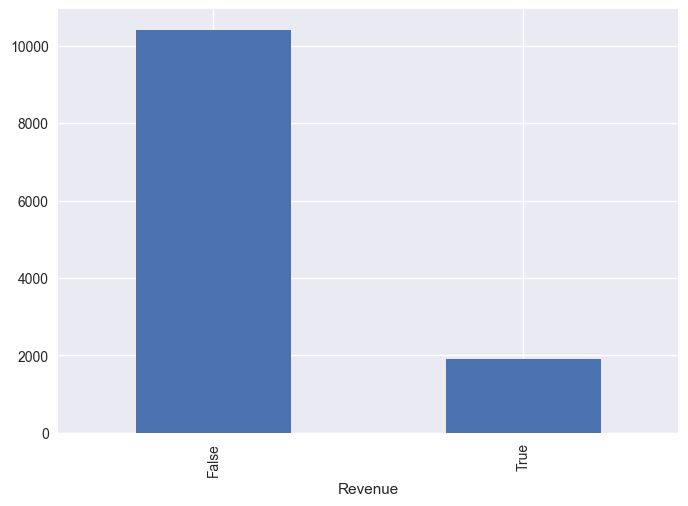

In [8]:
df['Revenue'].value_counts().plot(kind='bar')

## Target Variable Analysis

The target variable `Revenue` indicates whether a session resulted in a purchase.

### Class Distribution
- False (No Purchase): 10,422 sessions
- True (Purchase): 1,908 sessions

This means approximately:
- 84.5% of sessions did not result in a purchase
- 15.5% of sessions resulted in a purchase

### Class Balance
The dataset is **imbalanced**, with significantly more non-purchase sessions than purchase sessions. This is expected in real-world e-commerce data, where conversion rates are typically low.

Because of this imbalance, accuracy alone will not be a reliable evaluation metric. In later modeling steps, we may need to consider metrics such as precision, recall, F1-score, or ROC-AUC to properly evaluate performance.

## 4. Feature Distributions

For this step we will:
1. Define an index of feature names.
2. Generate a Histogram for all features.
3. Make observations of the data.

In [11]:
# get feature names
# I will isolate only the numeric features for now, but we can also look at the categorical features later
features = df.select_dtypes(include='number').columns
features

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

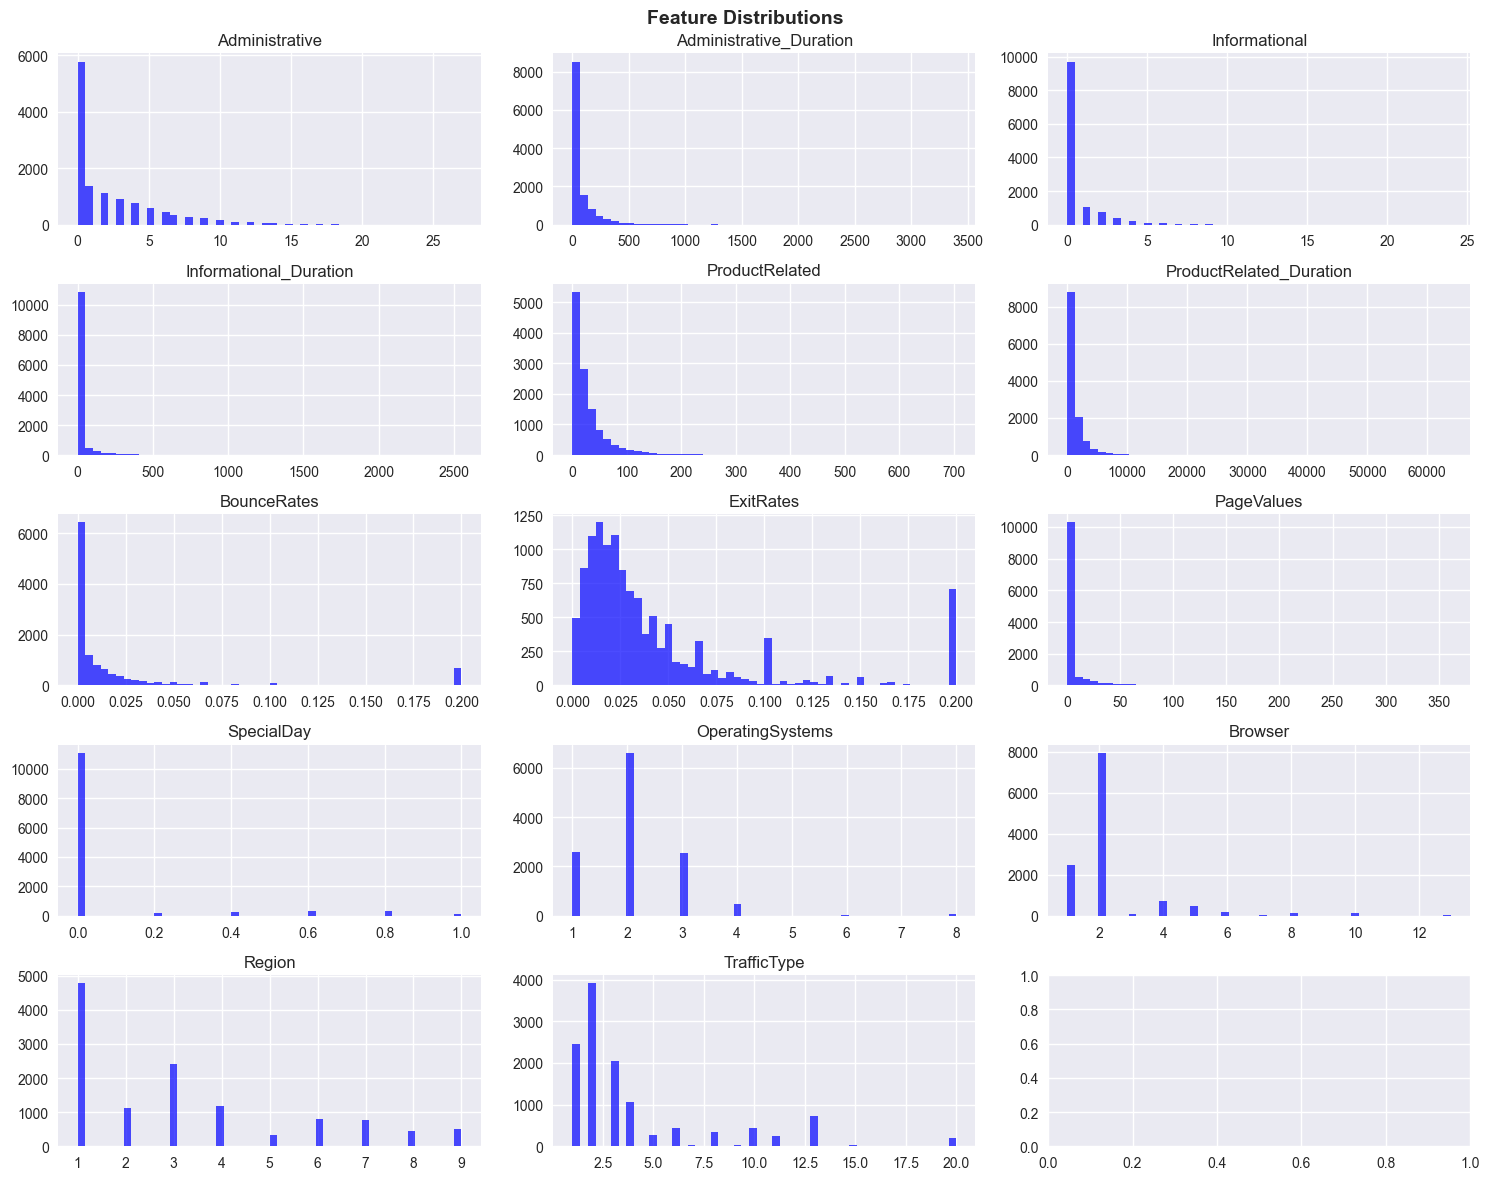

In [13]:
# histogram for all features
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=50, color='blue', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Distribution Observations

Features are on significantly different scales. For example, BounceRates range from 0 to .20 while ProductRelated_Duration ranges from 0 to over 63,000. This will require feature scaling before modeling. The histograms also appear to be right-skewed.



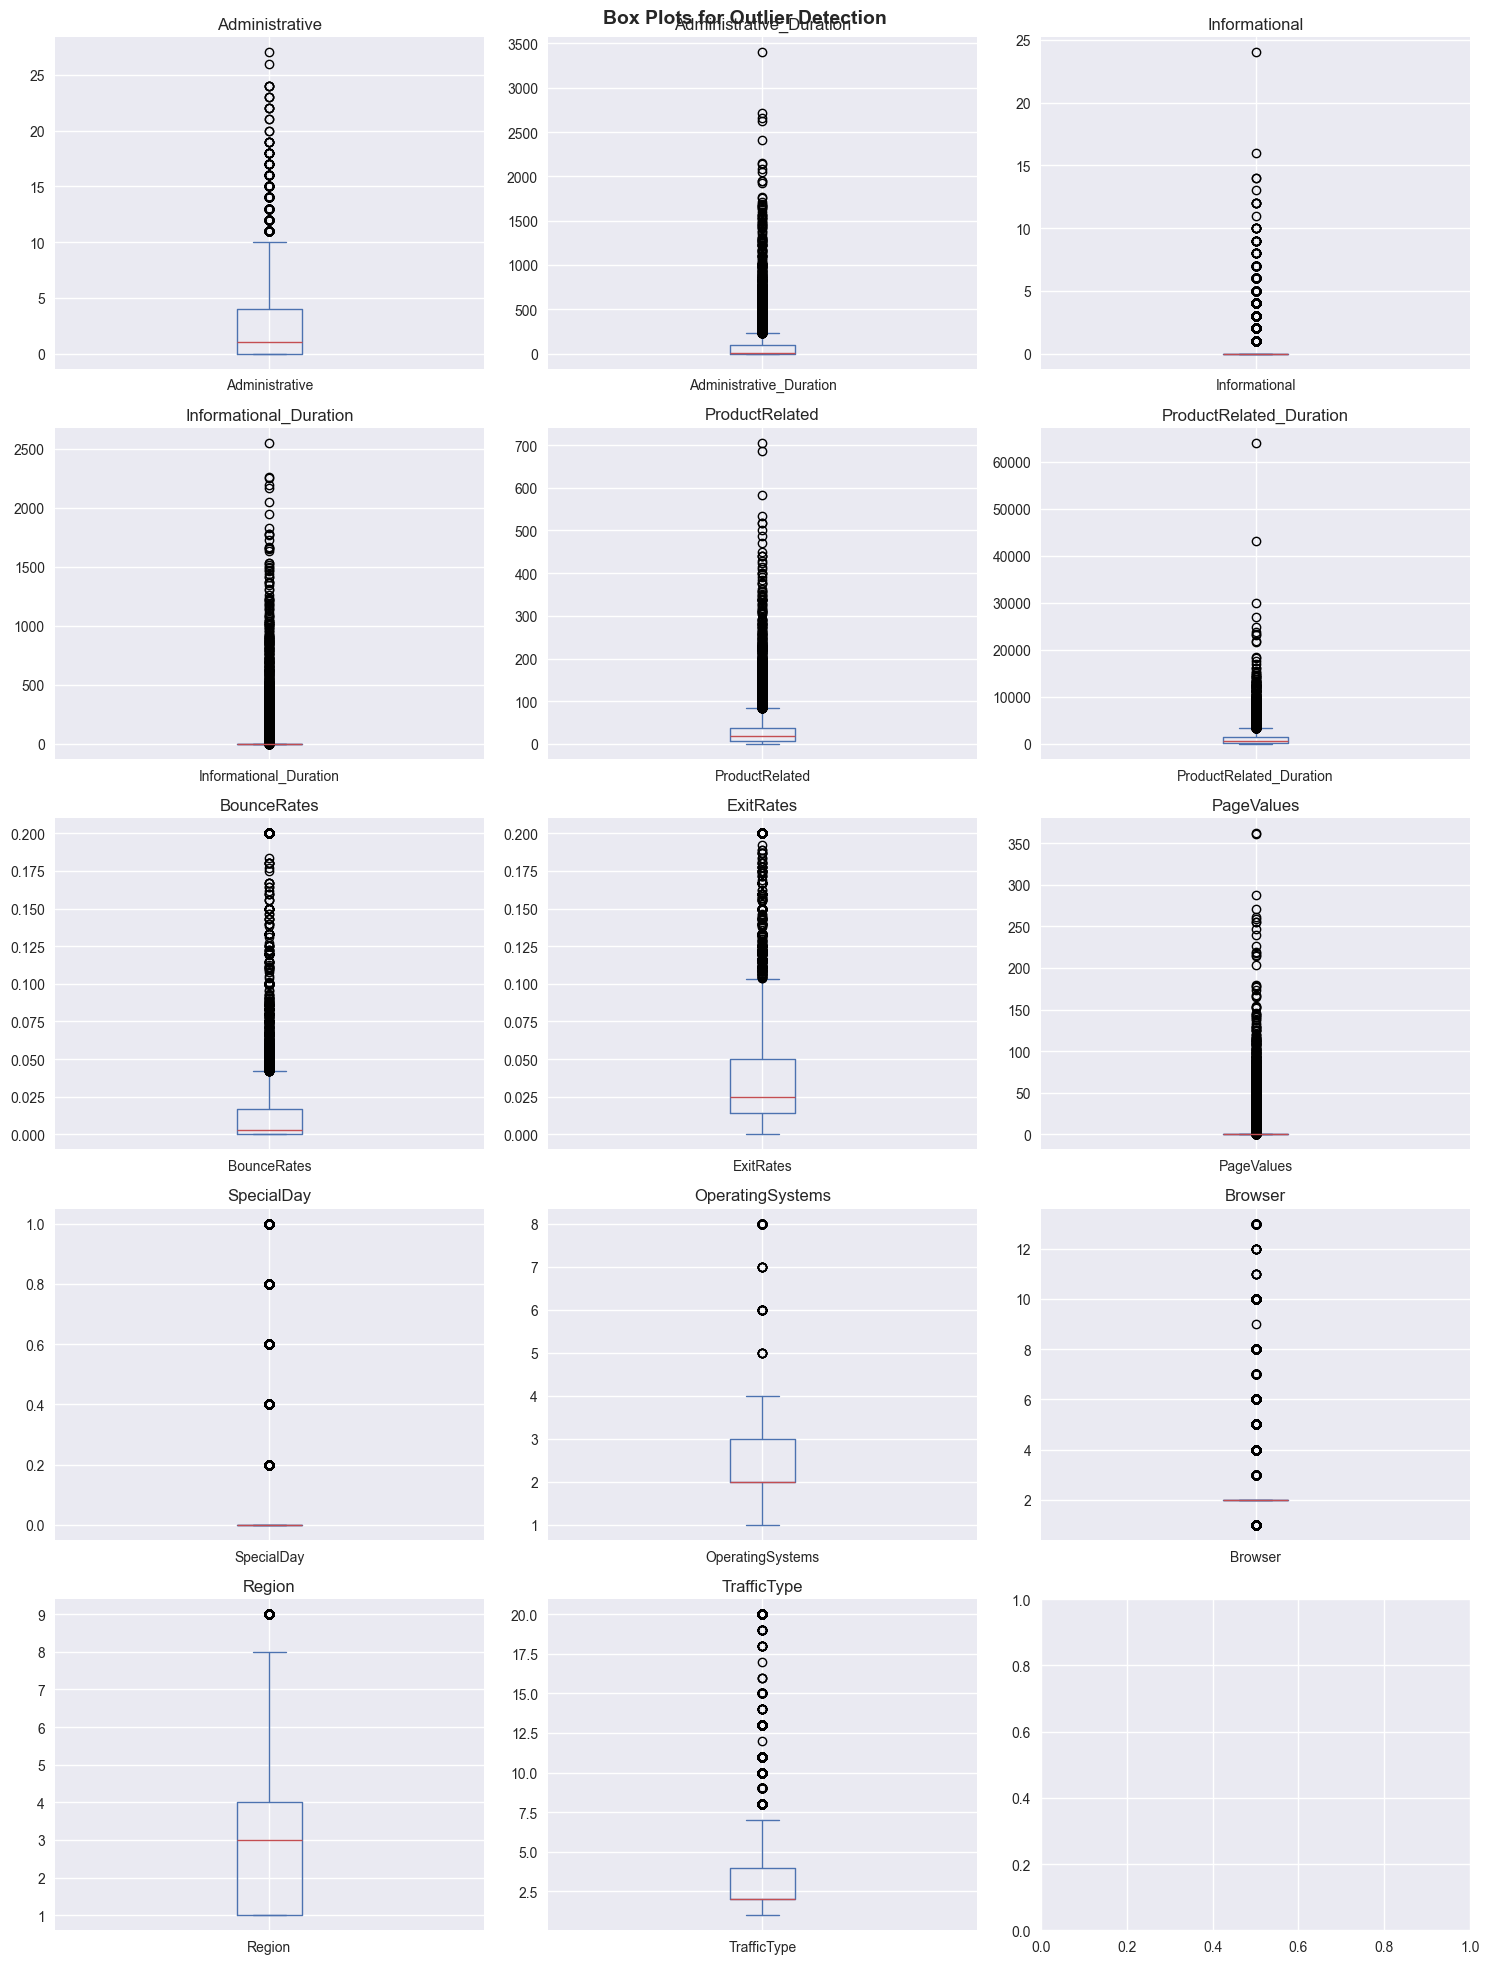

In [14]:
# box plots for all features
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    # Draw the box plot
    df[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Box Plot Analysis

Almost all numeric features, particularly duration and page metric, show a significant number of extreme outliers on the upper end. We will need to decide how to handle these (like capping or removing) before training the model.

In [17]:
# categorical features info
categorical_features = df.select_dtypes(include=['object', 'string', 'bool']).columns

# Drop 'Revenue' to avoid repeating Step 3
if 'Revenue' in categorical_features:
    categorical_features = categorical_features.drop('Revenue')

# Loop through each column individually
for col in categorical_features:
    print(f"--- {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts())
    print("\n")

--- Month ---
Unique values: 10
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


--- VisitorType ---
Unique values: 3
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


--- Weekend ---
Unique values: 2
Weekend
False    9462
True     2868
Name: count, dtype: int64





## 5. Correlation Analysis

### Correlation Observations

*TODO: Write your observations here*

1. **Strongest predictor:** ...
2. **Other important features:** ...
3. **Multicollinearity concerns:** ...


## 6. Key Findings Summary

## EDA Checklist

Before moving to modeling, ensure you've completed:

- [ ] Loaded and examined the data
- [ ] Checked data types
- [ ] Identified and documented missing values
- [ ] Analyzed target variable distribution
- [ ] Examined feature distributions
- [ ] Created correlation analysis
- [ ] Documented key findings
- [ ] Identified potential data quality issues